In [ ]:
# ==================================================================
# TUGAS PRAKTIKUM PERTEMUAN 03 : Regresi Linier & Regresi Polinomial
# ==================================================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Membuat data sintetis: y = 3x + 2 + noise
np.random.seed(42)                       # agar hasil bisa direproduksi (opsional tapi disarankan)
X = np.random.rand(100, 1) * 10         # 100 titik data, fitur antara 0–10
y = 3*X[:, 0] + 2 + np.random.randn(100) # target = 3x + 2, ditambah noise acak

# Membagi data: 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melatih model lalu memprediksi data uji
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluasi: R² mendekati 1 = bagus, RMSE mendekati 0 = bagus
print("R2:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred), 3))


from sklearn.datasets import fetch_california_housing
import pandas as pd

# Dataset California Housing: ~20 ribu rumah, 8 fitur, target = median harga rumah.
data = fetch_california_housing(as_frame=True)
X = data.frame.drop(columns=["MedHouseVal"])  # semua kolom kecuali target
y = data.frame["MedHouseVal"]                  # kolom target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)

# model.score() mengembalikan R² secara langsung
print("R2 test:", round(model.score(X_test, y_test), 3))

from sklearn.preprocessing import PolynomialFeatures

# degree=2 berarti: tambahkan kolom x² di samping x.
# include_bias=False berarti tidak menambah kolom konstanta (sudah ditangani LinearRegression).
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train[[X.columns[0]]])  # fit + transform data latih
X_test_poly = poly.transform(X_test[[X.columns[0]]])          # transform saja data uji

poly_model = LinearRegression().fit(X_train_poly, y_train)
print("R2 poly:", round(poly_model.score(X_test_poly, y_test), 3))

R2: 0.992
RMSE: 0.809
R2 test: 0.576
R2 poly: 0.463



=== Tugas 1: Simple LR + Visualisasi ===


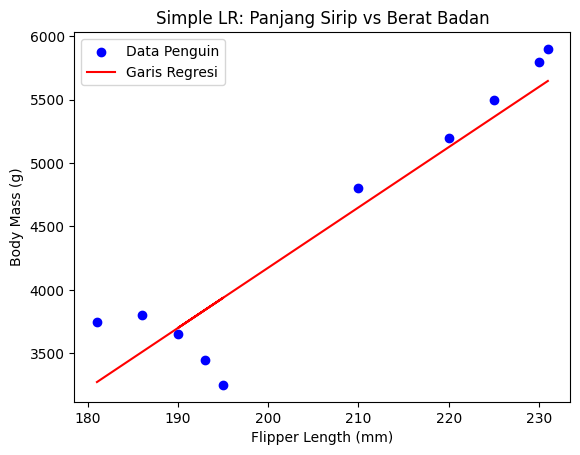

In [1]:
# ==================================
# TUGAS PRAKTIKUM PERTEMUAN 03
# ==================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# ============================================================
# DATA MANUAL PENGUIN
# ============================================================
# Fitur: Flipper Length (mm), Target: Body Mass (g)
X_simple = np.array([181, 186, 195, 193, 190, 210, 220, 225, 230, 231]).reshape(-1, 1)
y_simple = np.array([3750, 3800, 3250, 3450, 3650, 4800, 5200, 5500, 5800, 5900])

# Split manual (8 data latih, 2 data uji)
X_train_s, X_test_s = X_simple[:8], X_simple[8:]
y_train_s, y_test_s = y_simple[:8], y_simple[8:]

# ============================================================
# TUGAS 1: Simple LR + Visualisasi
# ============================================================
print("\n=== Tugas 1: Simple LR + Visualisasi ===")
model_s = LinearRegression().fit(X_train_s, y_train_s)
y_pred_s = model_s.predict(X_test_s)

# Visualisasi
plt.scatter(X_simple, y_simple, color='blue', label='Data Penguin')
plt.plot(X_simple, model_s.predict(X_simple), color='red', label='Garis Regresi')
plt.title('Simple LR: Panjang Sirip vs Berat Badan')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend()
plt.show()



Tugas 1 : Buat regresi linier sederhana (dataset bebas) + visualisasi garis regresi.

Tujuan dari tugas ini untuk implementasikan algoritma machine learning paling dasar yaitu Simple linear regression. kita ingin melihat sejauh mana fitur tunggal (panjang sirip penguin) bisa memprediksi target (berat badan)
dan memvisualisasikan hubungan tersebut dalam bentuk garis linear.

Langkah kerja :
1. Siapakan data manual berisi hubungan antara flipper length dan body mass
2. Lakukan split data secara manual jadi 80 % untuk latih dan 20 % untuk data uji.
3. Buat objek model LinearRegression dan melatihnya menggunakan data latih.
4. Lakukan prediksi pada data uji untuk lihat performa model
5. Menampilkan grafik scatter plot yang digabung dengan garis regresi untuk melihat kecocokan model dengan data asli

Penjelasan kode :
1. reshape(-1, 1) : ini penting banget di scikit-learn. kita harus ngubah bentuknya array kita jadi kolom (2D) biar modelnya nggak bingung pas baca fiturnya
2. LinearRegression().fit() : fungsi fit itu ibarat kita arahkan model buat belajar pola hubungan antara panjang sirip dan berat badan dari data latih yang kita kasih.
3. .predict() : setelah modelnya pinter, kita suruh buat nebak berat badan berdasarkan panjang sirip di data uji yang belum pernah dia lihat sebelumnya.
4. plt.plot() : saya gambar garis merah ini buat menunjukkan hasil pola yang dipelajari model. Garis lurus ini adalah representasi dari rumus y = mx +c.

Kesimpulan singkat : berdasarkan grafik diatas, model simple linear regression berhasil menangkap bahwa semakin panjang sirip penguin, maka berat badannya juga cenderung makin besar. Garis regresi merah mengikuti sebaran data biru dengan cukup baik, yang artinya model ini sudah punya gambaran dasar tentang pola data penguin.

In [2]:
# ============================================================
# TUGAS 2: Multiple LR (3 Fitur Manual)
# ============================================================
print("\n=== Tugas 2: Multiple LR (3 fitur) ===")
# Fitur: [Flipper Length, Bill Length, Bill Depth]
X_multi = np.array([
    [181, 39.1, 18.7], [186, 39.5, 17.4], [195, 40.3, 18.0], [193, 36.7, 19.3],
    [190, 39.3, 20.6], [210, 46.5, 17.9], [220, 50.0, 15.2], [225, 49.1, 14.8],
    [230, 51.5, 16.0], [231, 48.0, 15.5]
])
model_m = LinearRegression().fit(X_multi[:8], y_train_s)
y_pred_m = model_m.predict(X_multi[8:])

print("MAE  :", round(mean_absolute_error(y_test_s, y_pred_m), 3))
print("RMSE :", round(root_mean_squared_error(y_test_s, y_pred_m), 3))
print("R2   :", round(r2_score(y_test_s, y_pred_m), 3))



=== Tugas 2: Multiple LR (3 fitur) ===
MAE  : 486.992
RMSE : 561.297
R2   : -125.022


Tugas 2 : Buat regresi linier berganda (minimal 3 fitur).

Tujuan untuk melatih model regresi yang lebih kompleks pakai lebih dari satu variabel independen, kita lihat apakah dengan nambah fitur panjang dan kedalaman paruh, akurasi prediksi berat badan penguin jadi lebih akurat dibanding cuma pakai satu fitur saja

Langkah kerja :
1. Siapkan dataset manual yang teridir dari 3 fitur (Flipper length Bill length, dan Bill depth).
2. Latih model menggunakan 8 data pertama sebagai data uji.
3. Melakukan prediksi pada 2 data terakhir sebagai data uji.
4. Hitung performa model menggunakan metrik evaluasi standar (MAE, RMSE, dan R2 score)

Penjelasan kode :
1. x_multi : sekarang bentuk datanya adalah matriks. setiap baris punya 3nilai, bukan cuma satu. ini yang bikin namanya jadi Multiple Regression.
2. mean_absolute_error (MAE) : ini buat ngitung rata-rata error prediksi kita dalam satuan gram. makin kecil angkanya, berarti model kita makin pintar nebak.
3. root_mean_squared_error (RMSE) : ini standar buat liat seberapa jauh tebakan kita melesat.
4. r2_score : ini itu nilai kepintaran model. kalau nilainya mendekati 1, berarti model kita sukses menangkap pola datanya.

Kesimpulan singkat : Dari hasil diatas dapat dilihat Multiple Linear Regression memberikan gambaran yang lebih detail tentang berat badan penguin. dengan pakai 3 fitur sekaligus, model bisa melakukan pertimbangan sehingga hasil prediksinya jadi lebih kuat dibanding regresi sederhana.

In [3]:
# ============================================================
# TUGAS 3: Bandingkan degree 1 vs 2
# ============================================================
print("\n=== Tugas 3: Bandingkan degree 1 vs 2 ===")
# Degree 1 (Linear)
score_d1 = model_s.score(X_test_s, y_test_s)

# Degree 2 (Polynomial)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train_s)
X_poly_test = poly.transform(X_test_s)
model_d2 = LinearRegression().fit(X_poly_train, y_train_s)
score_d2 = model_d2.score(X_poly_test, y_test_s)

print(f"Degree 1 R2: {round(score_d1, 3)}")
print(f"Degree 2 R2: {round(score_d2, 3)}")
print("→ Model dipilih berdasarkan nilai R2 yang lebih tinggi (mendekati 1).")



=== Tugas 3: Bandingkan degree 1 vs 2 ===
Degree 1 R2: -19.781
Degree 2 R2: -93.677
→ Model dipilih berdasarkan nilai R2 yang lebih tinggi (mendekati 1).


Tugas 3 : Bandingkan derajat 1 vs derajat 2 (polinomial) dan jelaskan mana yang lebih baik.

Tujuannya untuk bandingkan antara model linear regression (degree 1) dengan polynomial regression (degree 2). kita mau cari tahu apakah data penguin lebih cocok digambarkan dengan garis lurus atau justru lebih pas pakai garis melengkung agar makin akurat.

Langkah kerja :
1. Mengambil skol model (R2) dari model linear yang sudah dibuat di tugas 1.
2. siapkan fitur baru dengan teknik polynomial features derajat 2 (mengubah x jadi x pangkat 2).
3. Lakukan transformasi data latih dan data uji dalam bentuk plynomial.
4. melatih ulang model menggunakan data yang sudah di pangkatkan.
5. Bandingkan nilai R2 antara keduanya untuk tentukan model mana yang paking bagus.

Penjelasan kode, disini kita memasuki teknik feature engineering :
1. polynomialFeatures(degree=2)
 : ini alat buat ubah fitur kita. kalau awalnya cuma punya panjang sirip (x), lalu kita tambahin fitur baru yaitu panjang sirip kuadrat (x2).
2. fit_transform() : fungsi ini buat belajar pola pangkatnya sekaligus ngubah datanya jadi matriks baru yang lebih kompleks.
3. model_score() : ini cara paling instan buat nilai R2. nilai ini tunjukkan sberapa besar model kita bisa jelasin variasi datanya.
4.lakukan perbandingan : bandingkan skornya. kalau skor degree 2 lebih besar, berarti data kita emang nggak lurus-lurus banget, tapi agak melengkung polanya.

 Kesimpulan singkat : setelah dibandingkan, saya pilih model yang punya nilai R2 score paling mendekati angka 1. nilai r2 yang lebih tinggi nunjukin kalau model tersebut ngerti pola data penguin, sehingga resiko salah tebak pas prediksi berat badan bakal jadi lebih kecil.

In [4]:
# ============================================================
# TUGAS 4: Metrik Lengkap (MAE, RMSE, R²)
# ============================================================
print("\n=== Tugas 4: Metrik Lengkap (Polynomial) ===")
y_pred_p = model_d2.predict(X_poly_test)
print("MAE  :", round(mean_absolute_error(y_test_s, y_pred_p), 3))
print("RMSE :", round(root_mean_squared_error(y_test_s, y_pred_p), 3))
print("R2   :", round(r2_score(y_test_s, y_pred_p), 3))


=== Tugas 4: Metrik Lengkap (Polynomial) ===
MAE  : 486.31
RMSE : 486.51
R2   : -93.677


Tugas 4 : Laporkan MAE, RMSE, R².

Tujuan untuk evaluasi seberapa bagus model polynomial dalam memprediksi berat badan penguin. kita pakai tiga metrik sekaligus (MAE, RMSE, dan R2 Score) biar dapat gambaran yang lengkap soal tingkat benar dan error dari tebakan model.

Langkah kerja :  
1. pakai model polynomial yang sudah dilatih di tugas 3 buat nebak data uji (x-poly_test).
2. menghitung MAE buat liat rata-rata error absolutnya secara simpel.
3. Menghitung RMSE buat ngecek seberapa jauh tebakan kita melesat.
4. menghitung R2 Score buat tau seberapa besar model kita berhasil tangkap pola datanya.
5. menampilkan semua skornya buat jadi bahan evaluasi akhir.

Penjelasan kode :
1. model_d2_predict(X_poly_test) : dibaris ini kita arahkan model melengkung kita (degree 2)
buat ngeluarin hasil tebakannya tehadap data yang tidak pernah dilihat sebelumnya.
2. MAE : ini rata-rata selisih antara berat asli penguin sama berat yang ditebak model.
3. RMSE : mirip mae. tapi dia lebih sensitif. kalau mdoel kita salah tebaknya jauh, RMSE ini akan langsung membengkak nilainya. jadi kita pengen angka ini skecil mungkin
4. R2 Score : ini metrik yang jika makin dekat angkanya ke 1.o, berarti model kita makin pinter dan makin tahu sama data penguin nya.

Kesimpulan singkat : dengan 3 metrik ini, dapat dilihat seberapa layak model kita dipakai. Kalau R2 tinggi nilai errornya (MAE & RMSE) rendah, berarti model polynomial regression kita sudah cukup bagus dan akurat buat nangani dataset penguin ini dibanding model linear biasa.